In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import GradientBoostingClassifier


In [ ]:
df = pd.read_csv("/content/dataset1.csv").drop_duplicates()

In [ ]:
if 2 in df['Output'].unique():
    df['Output'] = df['Output'].replace({2:1})

In [ ]:
X = df.drop("Output", axis=1)
y = df["Output"]


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("select", SelectKBest(score_func=f_classif, k=50)),
    ("scale", StandardScaler()),
    ("gb", GradientBoostingClassifier(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=5,
        random_state=42
    ))
])

In [ ]:
model.fit(X_train, y_train)


Pipeline(steps=[('poly',
                 PolynomialFeatures(include_bias=False, interaction_only=True)),
                ('select', SelectKBest(k=50)), ('scale', StandardScaler()),
                ('gb',
                 GradientBoostingClassifier(learning_rate=0.03, max_depth=5,
                                            n_estimators=1200,
                                            random_state=42))])

In [ ]:
preds = model.predict(X_test)

In [ ]:
print("Test Accuracy: {:.2f}%".format(accuracy_score(y_test, preds)*100))
print("\nClassification Report:\n", classification_report(y_test, preds))

Test Accuracy: 94.89%

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94        80
           1       0.96      0.95      0.95        96

    accuracy                           0.95       176
   macro avg       0.95      0.95      0.95       176
weighted avg       0.95      0.95      0.95       176



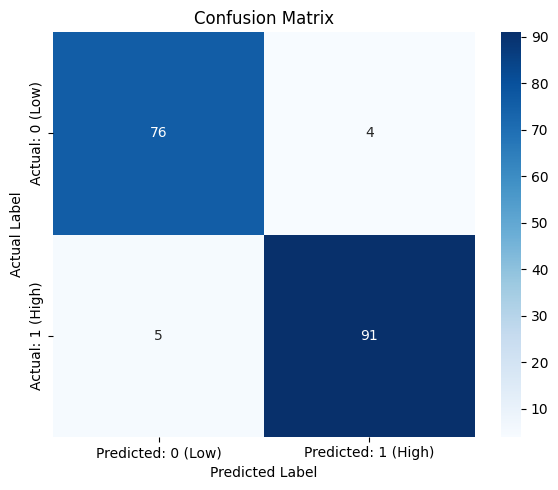

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Predicted: 0 (Low)', 'Predicted: 1 (High)'],
            yticklabels=['Actual: 0 (Low)', 'Actual: 1 (High)'])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


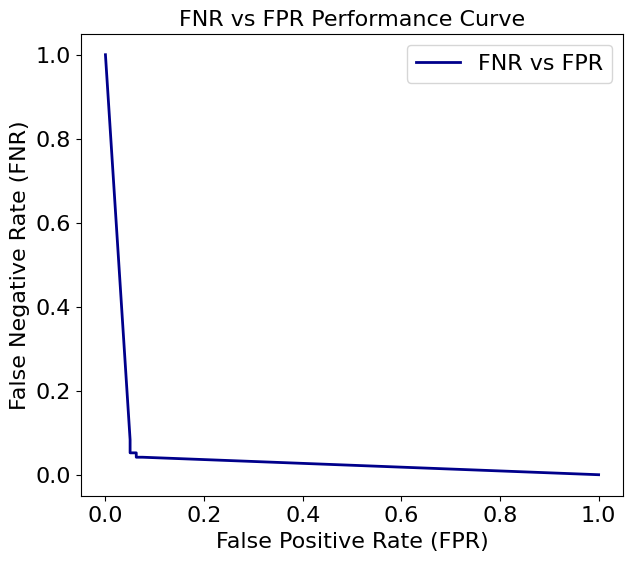

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


y_prob = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0, 1, 100)

fnr_list = []
fpr_list = []

for thresh in thresholds:

    y_pred_thresh = (y_prob >= thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()

    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) != 0 else 0

    fpr_list.append(fpr)
    fnr_list.append(fnr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_list, fnr_list,
    color='darkblue',
    linewidth=2,
    label='FNR vs FPR'
)

plt.xlabel("False Positive Rate (FPR)", fontsize=16, fontname='Times New Roman')
plt.ylabel("False Negative Rate (FNR)", fontsize=16, fontname='Times New Roman')
plt.title("FNR vs FPR Performance Curve", fontsize=16, fontname='Times New Roman')


plt.xticks(fontsize=16, fontname='Times New Roman')
plt.yticks(fontsize=16, fontname='Times New Roman')


plt.legend(prop={'family':'Times New Roman', 'size':16})


plt.grid(False)

plt.show()


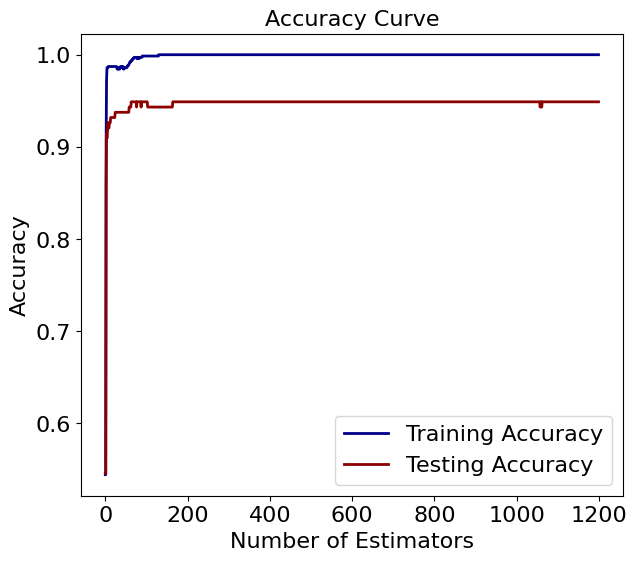

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


gb_model = model.named_steps['gb']

train_acc = []
test_acc = []

for y_train_pred, y_test_pred in zip(
    gb_model.staged_predict(model[:-1].transform(X_train)),
    gb_model.staged_predict(model[:-1].transform(X_test))
):
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(7,6))

plt.plot(train_acc, color='darkblue', linewidth=2, label='Training Accuracy')
plt.plot(test_acc, color='darkred', linewidth=2, label='Testing Accuracy')

plt.xlabel("Number of Estimators", fontsize=16, fontname='Times New Roman')
plt.ylabel("Accuracy", fontsize=16, fontname='Times New Roman')
plt.title("Accuracy Curve", fontsize=16, fontname='Times New Roman')

plt.xticks(fontsize=16, fontname='Times New Roman')
plt.yticks(fontsize=16, fontname='Times New Roman')

plt.legend(prop={'family':'Times New Roman','size':16})

plt.grid(False)
plt.show()


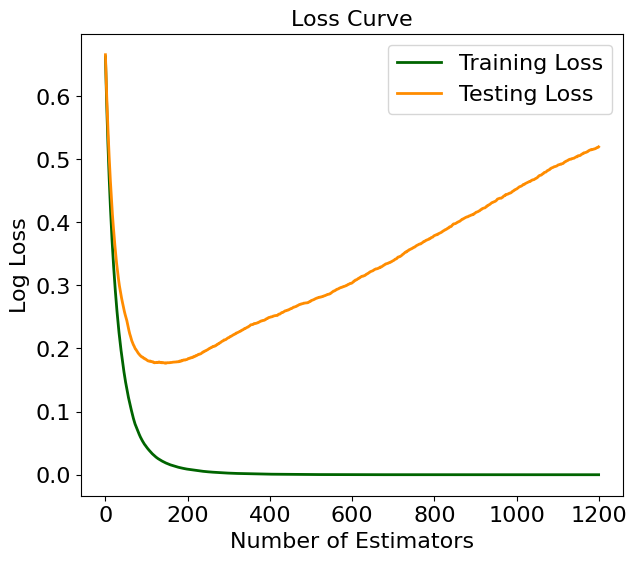

In [ ]:
from sklearn.metrics import log_loss

train_loss = []
test_loss = []

for y_train_prob, y_test_prob in zip(
    gb_model.staged_predict_proba(model[:-1].transform(X_train)),
    gb_model.staged_predict_proba(model[:-1].transform(X_test))
):
    train_loss.append(log_loss(y_train, y_train_prob))
    test_loss.append(log_loss(y_test, y_test_prob))

plt.figure(figsize=(7,6))

plt.plot(train_loss, color='darkgreen', linewidth=2, label='Training Loss')
plt.plot(test_loss, color='darkorange', linewidth=2, label='Testing Loss')

plt.xlabel("Number of Estimators", fontsize=16, fontname='Times New Roman')
plt.ylabel("Log Loss", fontsize=16, fontname='Times New Roman')
plt.title("Loss Curve", fontsize=16, fontname='Times New Roman')

plt.xticks(fontsize=16, fontname='Times New Roman')
plt.yticks(fontsize=16, fontname='Times New Roman')

plt.legend(prop={'family':'Times New Roman','size':16})

plt.grid(False)
plt.show()


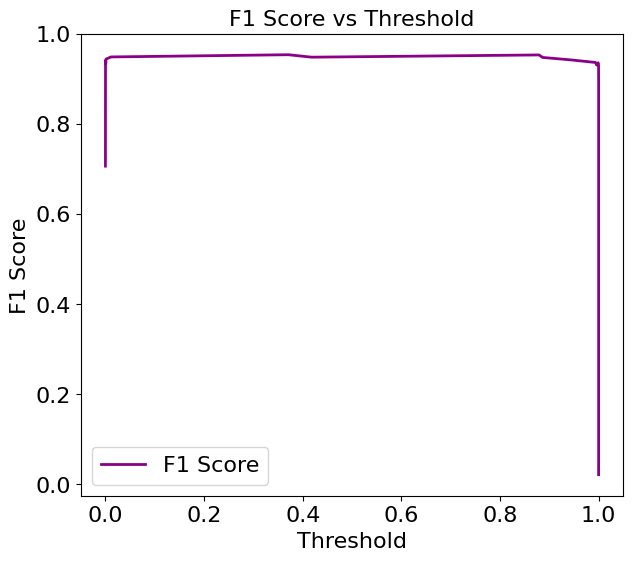

Best Threshold: 0.3708745623268458
Best F1 Score: 0.9533678755976698


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)


f1_scores = f1_scores[:-1]

plt.figure(figsize=(7,6))

plt.plot(
    thresholds,
    f1_scores,
    color='darkmagenta',
    linewidth=2,
    label='F1 Score'
)

plt.xlabel("Threshold", fontsize=16, fontname='Times New Roman')
plt.ylabel("F1 Score", fontsize=16, fontname='Times New Roman')
plt.title("F1 Score vs Threshold", fontsize=16, fontname='Times New Roman')

plt.xticks(fontsize=16, fontname='Times New Roman')
plt.yticks(fontsize=16, fontname='Times New Roman')

plt.legend(prop={'family':'Times New Roman', 'size':16})

plt.grid(False)

plt.show()


best_threshold = thresholds[np.argmax(f1_scores)]
print("Best Threshold:", best_threshold)
print("Best F1 Score:", np.max(f1_scores))


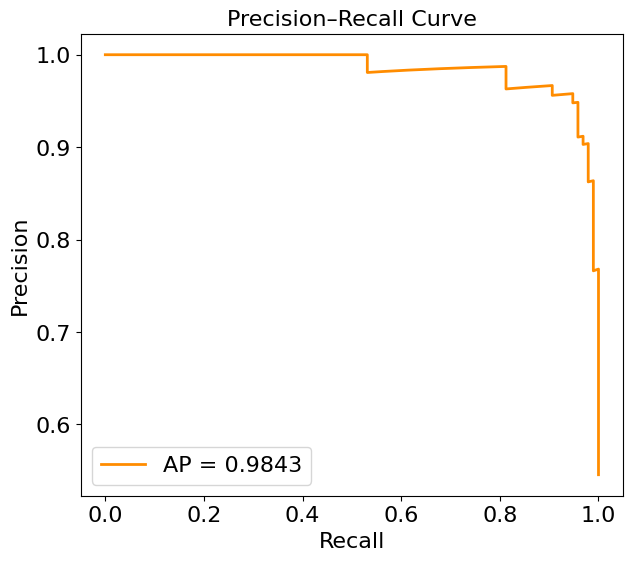

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score


y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    recall,
    precision,
    color='darkorange',
    linewidth=2,
    label=f'AP = {ap_score:.4f}'
)

plt.xlabel("Recall", fontsize=16, fontname='Times New Roman')
plt.ylabel("Precision", fontsize=16, fontname='Times New Roman')
plt.title("Precision–Recall Curve", fontsize=16, fontname='Times New Roman')

plt.xticks(fontsize=16, fontname='Times New Roman')
plt.yticks(fontsize=16, fontname='Times New Roman')

plt.legend(prop={'family':'Times New Roman', 'size':16})

plt.grid(False)

plt.show()


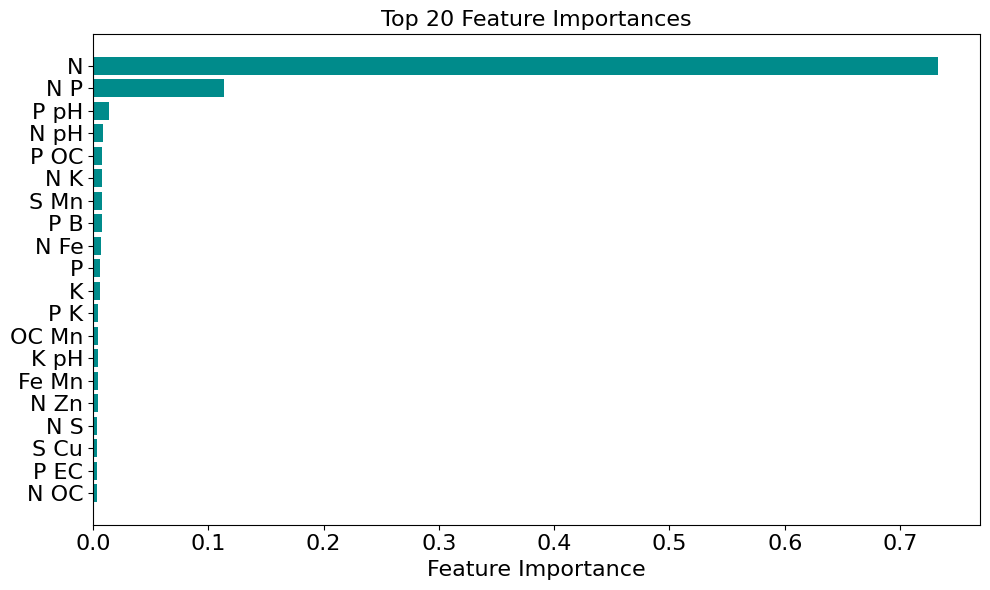

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

poly = model.named_steps['poly']
select = model.named_steps['select']

poly_features = poly.get_feature_names_out(X.columns)
selected_features = poly_features[select.get_support()]

importances = model.named_steps['gb'].feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))

plt.barh(
    range(len(indices)),
    importances[indices],
    color='darkcyan'
)

plt.yticks(
    range(len(indices)),
    selected_features[indices],
    fontsize=16,
    fontname='Times New Roman'
)

plt.xticks(fontsize=16, fontname='Times New Roman')

plt.xlabel("Feature Importance", fontsize=16, fontname='Times New Roman')
plt.title("Top 20 Feature Importances", fontsize=16, fontname='Times New Roman')

plt.grid(False)

plt.tight_layout()
plt.show()


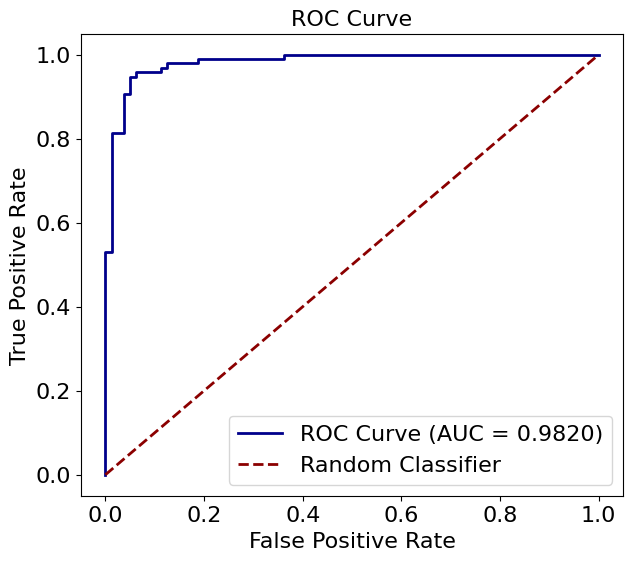

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


y_prob = model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))


plt.plot(
    fpr,
    tpr,
    color='darkblue',
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)


plt.plot(
    [0, 1],
    [0, 1],
    color='darkred',
    linewidth=2,
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate", fontsize=16, fontname='Times New Roman')
plt.ylabel("True Positive Rate", fontsize=16, fontname='Times New Roman')
plt.title("ROC Curve", fontsize=16, fontname='Times New Roman')

plt.xticks(fontsize=16, fontname='Times New Roman')
plt.yticks(fontsize=16, fontname='Times New Roman')

plt.legend(prop={'family':'Times New Roman', 'size':16})

plt.grid(False)

plt.show()
